# Pre-Processing

In [1]:
import scanpy as sc
tcell=sc.read_h5ad('/lustre/scratch126/cellgen/team298/rb34/data/tcell_raw_matrix_annotated.h5ad')

In [16]:
tcell.obs['final_anno']

AAACCTGAGACAAAGG-1             NKT
AAACCTGAGCGTTCCG-1       CD8_naive
AAACCTGAGTGTTTGC-1      CD4_memory
AAACCTGCAAACTGTC-1             NKT
AAACCTGCACAACGTT-1       CD4_naive
                           ...    
TTTATGCAGTGCGATG-1       CD4_naive
TTTGCGCTCGTCTGAA-1-1    NK_CD56dim
TTTGCGCTCTAACTCT-1      CD4_memory
TTTGGTTGTATATGAG-1       CD8_naive
TTTGTCAAGCGTGAGT-1       CD4_naive
Name: final_anno, Length: 69370, dtype: category
Categories (11, object): ['CD4_memory', 'CD4_naive', 'CD8_CM', 'CD8_EM', ..., 'NK_CD56bright', 'NK_CD56dim', 'Treg', 'gdT']

In [3]:
bcell=sc.read_h5ad('/lustre/scratch126/cellgen/team298/rb34/data/bcell_raw_matrix_annotated_allanno.h5ad')

In [17]:
bcell.obs['final_anno']

AAACGGGGTATAGTAG-1    B_naive
AAACGGGGTATTACCG-1    B_naive
AAACGGGTCTCACATT-1    B_naive
AAAGATGCACATTTCT-1    B_naive
AAAGATGCACTAAGTC-1    B_naive
                       ...   
TTCTCAATCACGAAGG-1    B_naive
TTCTTAGTCTGATTCT-1    B_naive
TTGGAACTCGTGGGAA-1    B_naive
TTGGCAAAGAATAGGG-1    B_naive
TTTGTCATCCGCGGTA-1    B_naive
Name: final_anno, Length: 11964, dtype: category
Categories (8, object): ['B_naive', 'non-switched memory/CD11c', 'non-swtiched memory', 'plasma_IgA', 'plasma_IgG', 'plasma_IgM', 'plasma_dividing', 'switched memory']

In [5]:
myeloid=sc.read_h5ad('/lustre/scratch126/cellgen/team298/rb34/data/mcell_raw_matrix_annotated.h5ad')

In [18]:
myeloid.obs['final_anno']

AAAGCAACAAAGGCGT-1        HSPC
AACTCCCCAGGACGTA-1        HSPC
ACATGGTGTCGTGGCT-1    Int.mono
ACGGGTCTCGTCCAGG-1    CD14mono
AGCTCTCGTTCCAACA-1    CD14mono
                        ...   
TTTGGTTTCGGAATCT-1    Int.mono
TTTGTCAAGGCATGTG-1    Int.mono
TTTGTCACAAAGGAAG-1    CD14mono
TTTGTCATCAACACTG-1    CD14mono
TTTGTCATCACAACGT-1    CD14mono
Name: final_anno, Length: 40929, dtype: category
Categories (11, object): ['ASDC', 'CD14mono', 'CD14mono_M1', 'CD16mono', ..., 'HSPC', 'Int.mono', 'Platelet', 'pDC']

In [19]:
combined_data=tcell.concatenate(bcell,myeloid)

/tmp/ipykernel_3361400/3716584077.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  combined_data=tcell.concatenate(bcell,myeloid)


In [23]:
combined_data.var

,gene_ids,mt,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,GEX-0,GEX-2
MIR1302-2HG,MIR1302-2HG,False,2,0.000013,99.998724,2.0,True,True
FAM138A,FAM138A,False,0,0.000000,100.000000,0.0,True,True
OR4F5,OR4F5,False,0,0.000000,100.000000,0.0,True,True
AL627309.1,AL627309.1,False,94,0.000606,99.940038,95.0,True,True
AL627309.3,AL627309.3,False,2,0.000013,99.998724,2.0,True,True
...,...,...,...,...,...,...,...,...
AC141272.1,AC141272.1,False,34,0.001371,99.978312,215.0,True,True
AC023491.2,AC023491.2,False,1,0.000006,99.999362,1.0,True,True
AC007325.1,AC007325.1,False,20,0.000128,99.987242,20.0,True,True
AC007325.4,AC007325.4,False,102,0.000670,99.934935,105.0,True,True


In [24]:
# mitochondrial genes
combined_data.var["mt"] = combined_data.var_names.str.startswith("MT-")
# ribosomal genes
combined_data.var["ribo"] = combined_data.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes.
combined_data.var["hb"] = combined_data.var_names.str.contains(("^HB[^(P)]"))

In [25]:
sc.pp.calculate_qc_metrics(
    combined_data, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)
combined_data

AnnData object with n_obs × n_vars = 122263 × 35976
    obs: 'patient_id', 'time_after_LPS', 'Sex', 'age', 'batch', 'IR_VJ_1_locus_tcr', 'IR_VJ_2_locus_tcr', 'IR_VDJ_1_locus_tcr', 'IR_VDJ_2_locus_tcr', 'IR_VJ_1_cdr3_tcr', 'IR_VJ_2_cdr3_tcr', 'IR_VDJ_1_cdr3_tcr', 'IR_VDJ_2_cdr3_tcr', 'IR_VJ_1_cdr3_nt_tcr', 'IR_VJ_2_cdr3_nt_tcr', 'IR_VDJ_1_cdr3_nt_tcr', 'IR_VDJ_2_cdr3_nt_tcr', 'IR_VJ_1_expr_tcr', 'IR_VJ_2_expr_tcr', 'IR_VDJ_1_expr_tcr', 'IR_VDJ_2_expr_tcr', 'IR_VJ_1_expr_raw_tcr', 'IR_VJ_2_expr_raw_tcr', 'IR_VDJ_1_expr_raw_tcr', 'IR_VDJ_2_expr_raw_tcr', 'IR_VJ_1_v_gene_tcr', 'IR_VJ_2_v_gene_tcr', 'IR_VDJ_1_v_gene_tcr', 'IR_VDJ_2_v_gene_tcr', 'IR_VJ_1_d_gene_tcr', 'IR_VJ_2_d_gene_tcr', 'IR_VDJ_1_d_gene_tcr', 'IR_VDJ_2_d_gene_tcr', 'IR_VJ_1_j_gene_tcr', 'IR_VJ_2_j_gene_tcr', 'IR_VDJ_1_j_gene_tcr', 'IR_VDJ_2_j_gene_tcr', 'IR_VJ_1_c_gene_tcr', 'IR_VJ_2_c_gene_tcr', 'IR_VDJ_1_c_gene_tcr', 'IR_VDJ_2_c_gene_tcr', 'IR_VJ_1_junction_ins_tcr', 'IR_VJ_2_junction_ins_tcr', 'IR_VDJ_1_junction_ins_tcr

In [26]:
import seaborn as sns


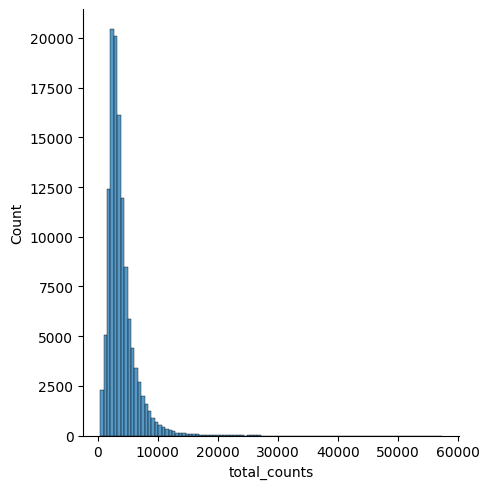

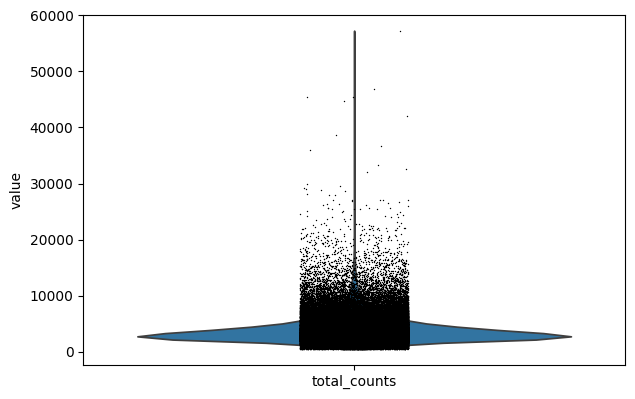

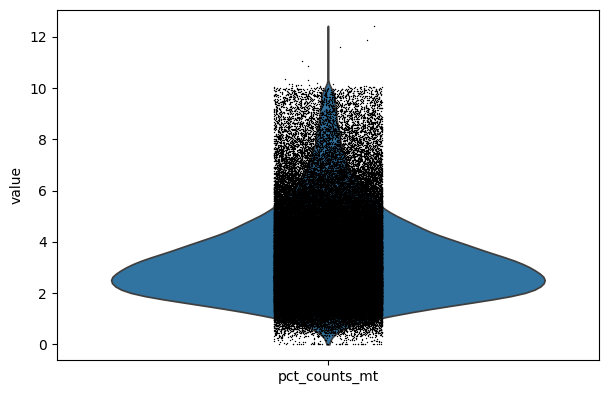

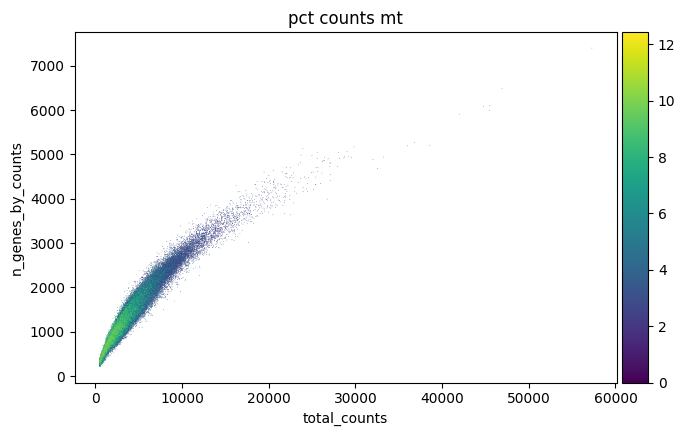

In [27]:
p1 = sns.displot(combined_data.obs["total_counts"], bins=100, kde=False)
sc.pl.violin(combined_data, 'total_counts')
p2 = sc.pl.violin(combined_data, "pct_counts_mt")
p3 = sc.pl.scatter(combined_data, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [29]:
combined_data = combined_data[combined_data.obs['pct_counts_mt'] <= 8]

In [31]:
sc.pp.filter_cells(combined_data, max_counts=150000)

/lustre/scratch126/cellgen/team283/Adib/mambaforge/envs/pertpy/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:158: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_counts"] = number


/tmp/ipykernel_3361400/3987137127.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(combined_data.obs['n_genes'], kde=False, bins=60)


<Axes: xlabel='n_genes'>

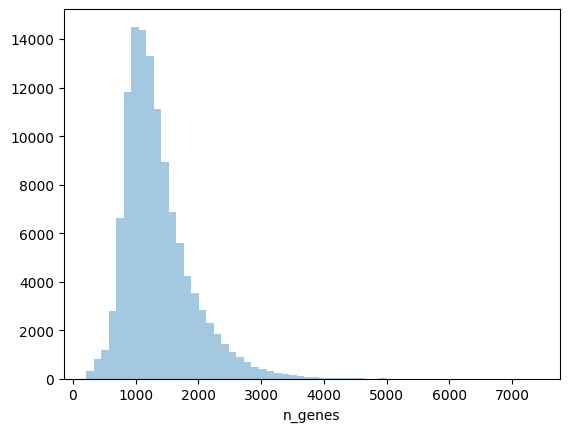

In [35]:
combined_data.obs['n_genes'] = (combined_data.X > 0).sum(1)
sns.distplot(combined_data.obs['n_genes'], kde=False, bins=60)

In [37]:
sc.pp.filter_genes(combined_data, min_cells=20)
print('Number of genes after cell filter: {:d}'.format(combined_data.n_vars))

Number of genes after cell filter: 19186


In [63]:
# Assuming `adata` is your AnnData object
combined_data.obs['batch'] = combined_data.obs['batch'].cat.rename_categories({
    '0': 'T cell lineage',
    '1': 'B cell lineage',
    '2': 'Myeloid lineage'
})


In [67]:
combined_data.write_h5ad('./raw_data.h5ad')